In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\LSRA\\Data_cleaning\\kaggle_merged\\merged_music_dataset.csv")
# Define the subset of emotion classes you want to keep
selected_classes = ["anger", "fear", "romantic", "sadness"]

# Filter the DataFrame to include only those classes
df_subset = df[df["final_emotion"].isin(selected_classes)]


In [22]:
balanced_df = (
    df_subset.groupby('final_emotion', group_keys=False)
      # .apply(lambda x: x.sample(2500, random_state=42))
      # .apply(lambda x: x.sample(1250, random_state=42))
      .apply(lambda x: x.sample(1667, random_state=42))
      .reset_index(drop=True)
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_42024\2610215155.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1667, random_state=42))


In [23]:
balanced_df['final_emotion'].value_counts()


final_emotion
anger       1667
fear        1667
romantic    1667
sadness     1667
Name: count, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    balanced_df['cleaned_lyrics'],
    balanced_df['final_emotion'],
    test_size=0.2,
    stratify=balanced_df['final_emotion'],
    random_state=42
)

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LinearSVC()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       anger       0.47      0.46      0.47       334
        fear       0.41      0.39      0.40       333
    romantic       0.50      0.51      0.50       334
     sadness       0.42      0.44      0.43       333

    accuracy                           0.45      1334
   macro avg       0.45      0.45      0.45      1334
weighted avg       0.45      0.45      0.45      1334



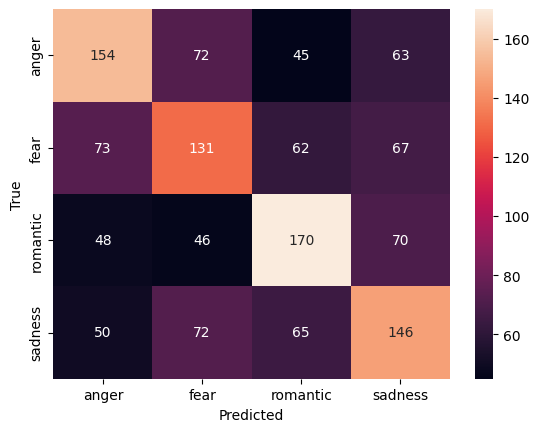

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
